Exploration Summary:-

-we have a dataFrame consisting of 9827 rows and 9 columns.

-Our DataFrame looks a bit tidy with no NaNs or Duplicated values.

-Release_Date column needs to be casted into Date Time and to extract only the year value.

-Overview, Original_Language and Poster-Url wouldn't be so useful during analysis, so we well drop them.

-There is noticable outliers in Popularity column.

-Vote_Average better be categorised for proper analysis.

-Genre column has comma seperated values and white spaces that needs to be handled and casted into category.exploration summary.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/mymoviedb.csv", lineterminator= '\n')

In [4]:
df

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
...,...,...,...,...,...,...,...,...,...
9822,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9823,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9824,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9825,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
print(df.describe())

        Popularity    Vote_Count  Vote_Average
count  9827.000000   9827.000000   9827.000000
mean     40.326088   1392.805536      6.439534
std     108.873998   2611.206907      1.129759
min      13.354000      0.000000      0.000000
25%      16.128500    146.000000      5.900000
50%      21.199000    444.000000      6.500000
75%      35.191500   1376.000000      7.100000
max    5083.954000  31077.000000     10.000000


In [8]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')


print(df['Release_Date'].dtype)

datetime64[ns]


In [9]:
df['Release_Date'] = df['Release_Date'].dt.year

df['Release_Date'].dtype

df['Release_Date'].head()

,Release_Date
0,2021
1,2022
2,2022
3,2021
4,2021


In [10]:
#Dropping the colummns

cols = ["Overview", "Original_Language", "Poster_Url"]
df.drop(cols, axis= 1, inplace=True, errors='ignore')

In [11]:
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [12]:
def catigorize_col(df, col, labels):
    edges = [
        df[col].describe()['min'],
        df[col].describe()['25%'],
        df[col].describe()['50%'],
        df[col].describe()['75%'],
        df[col].describe()['max']
    ]
    df[col] = pd.cut(df[col], edges, labels=labels, duplicates='drop')
    return df

In [13]:
labels = ["Not_Popular", "Below_Avg", "Above_Avg", "Popular"]

catigorize_col(df, 'Vote_Average', labels)

df['Vote_Average'].unique()

['Popular', 'Below_Avg', 'Above_Avg', 'Not_Popular', NaN]
Categories (4, object): ['Not_Popular' < 'Below_Avg' < 'Above_Avg' < 'Popular']

In [14]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,Popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,Below_Avg,Thriller
3,2021,Encanto,2402.201,5076,Popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,Above_Avg,"Action, Adventure, Thriller, War"


In [15]:
df['Vote_Average'].value_counts()

,count
Vote_Average,
Not_Popular,2467
Popular,2450
Above_Avg,2412
Below_Avg,2398


In [16]:
df.dropna(inplace=True)

df.isna().sum()

,0
Release_Date,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,0
Genre,0


we'd split genres into a list and then explode our DataFrame to have only one genre per row for each movie

In [17]:
df['Genre'] = df['Genre'].str.split(', ')

df = df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Popular,Crime
4,2022,The Batman,3827.658,1151,Popular,Mystery


In [18]:
#Casting columns into categories

df['Genre'] = df['Genre'].astype('category')
df['Genre'].dtype

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [19]:
df.info()



#Due to the normalization of multi-valued Genre entries using the explode function, the dataset expanded from 9,827 to 25,552 rows.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 749.6+ KB


In [20]:
sns.set_style('whitegrid')

1. What is the most frequent genre of movies released on netflix?

In [21]:
df['Genre'].describe()

,Genre
count,25552
unique,19
top,Drama
freq,3715


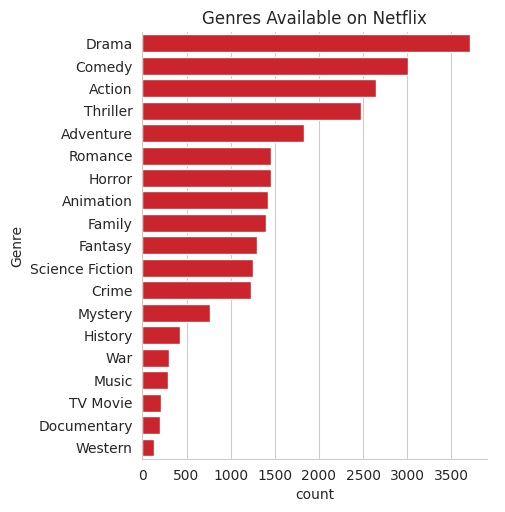

In [22]:
sns.catplot(
    data=df,
    y='Genre',
    kind='count',
    order=df['Genre'].value_counts().index,
    color='#E50914'
)

plt.title("Genres Available on Netflix")
plt.show()

2. Which Genre has highest votes

/tmp/ipykernel_7319/2441459210.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  genre_votes = df.groupby('Genre')['Vote_Count'].sum().sort_values(ascending=False)


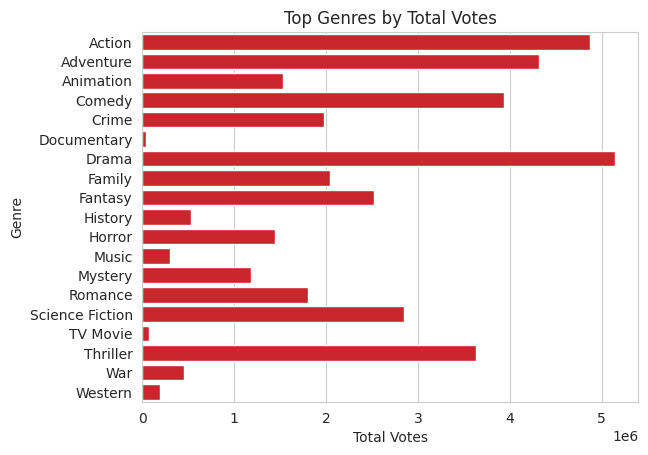

In [48]:
genre_votes = df.groupby('Genre')['Vote_Count'].sum().sort_values(ascending=False)

sns.barplot(x=genre_votes.values, y=genre_votes.index,  color='#E50914')

plt.title("Top Genres by Total Votes")
plt.xlabel("Total Votes")
plt.ylabel("Genre")

plt.show()

3. What movies got the highest popularity and what is its genre?


In [32]:
df[df['Popularity'] == df['Popularity'].max()][['Title', 'Genre']]

,Title,Genre
0,Spider-Man: No Way Home,Action
1,Spider-Man: No Way Home,Adventure
2,Spider-Man: No Way Home,Science Fiction


4. What movies got the lowest popularity and what is its genre?

In [37]:
df[df['Popularity'] == df['Popularity'].min()][['Title', 'Genre']]

,Title,Genre
25546,The United States vs. Billie Holiday,Music
25547,The United States vs. Billie Holiday,Drama
25548,The United States vs. Billie Holiday,History
25549,Threads,War
25550,Threads,Drama
25551,Threads,Science Fiction


5. Which year has the highest number of movies?

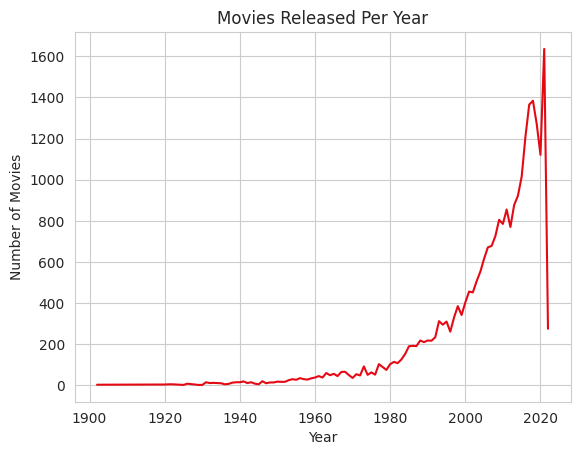

In [42]:
df['Release_Date'].value_counts().sort_index().plot(color='#E50914')

plt.title("Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.show()

Conclusion

Q1: What is the most frequent genre in the dataset?

Drama is the most frequent genre in the dataset, accounting for more than 14% of occurrences among all genres.

Q2: Which genre has the highest votes?

Drama is the genre with the highest total votes in the dataset, indicating that it receives the greatest audience engagement compared to other genres.”

Q3: Which movie has the highest popularity and what is its genre?

Spider-Man: No Way Home has the highest popularity in the dataset. It belongs to the Action, Adventure, and Science Fiction genres.

Q4: Which movie has the lowest popularity and what is its genre?

The United States vs. Billie Holiday and Threads has the lowest popularity in the dataset. It falls under multiple genres including Music, Drama, War, Science Fiction, and History.

Q5: Which year has the highest number of movies?

The year 2020 recorded the highest number of movie releases in the dataset.